# Notebook 2: Swap Experiment

**Does the composite look more like the image that donated the foreground (subject) or the image that donated the background (scene)?**

---

## Approach / Methodology

For each pair, the **foreground (main body)** is the intended answer. We combine this with the **same analysis style as the main VLM robustness notebook**: prompts/options → **softmax** over two options (source A vs B) → accuracy + **confidence** + **entropy**.

1. **Data:** All kinds of images from COCO val2017; subject = union of all object bboxes. We use **many pairs** (configurable, e.g. 200+) for more stable, research-level results. Composite 1 = A's foreground on B's background, Composite 2 = B's foreground on A's background.

2. **Correct vs wrong:** CLIP image similarity: composite vs A and vs B. We apply **softmax** (with temperature) to the two similarities to get a **probability** for A and B — same idea as the main eval (softmax over prompt options). If the model assigns higher probability to the **foreground** donor → **correct**; else **wrong**.

3. **Accuracy + research-level metrics:** We report accuracy (composite vs non-composite baseline). We also report **mean confidence** when correct vs when wrong, and **entropy** (uncertainty) over predictions, so the analysis is comparable to the main notebook and more informative than a single accuracy number.

4. **Output:** Accuracy chart, **confidence-by-correct/wrong** and **entropy distribution** charts, example 2×2 grids, and saved summary (including confidence/entropy).

## 1. Setup and Imports

In [66]:
import random
from pathlib import Path
from typing import List, Tuple

import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device("mps" if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


## 2. Configuration

In [74]:
CONFIG = {
    "coco_root": "data/coco",
    "coco_ann_file": "data/coco/annotations/instances_val2017.json",
    "coco_image_subdir": "val2017",
    "max_pairs": 1000,  # use many pairs for research-level results; set to 0 to use ALL available pairs
    "clip_model": "openai/clip-vit-base-patch32",
    "num_example_outputs": 2,
    "softmax_temperature": 1.0,  # temperature for similarity -> probability (align with main eval)
}

## 3. Load CLIP

In [75]:
from transformers import CLIPProcessor, CLIPModel

clip_processor = CLIPProcessor.from_pretrained(CONFIG["clip_model"])
clip_model = CLIPModel.from_pretrained(CONFIG["clip_model"]).to(device).eval()
print(f"Loaded {CONFIG['clip_model']}")

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 619.56it/s, Materializing param=visual_projection.weight]                                
CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded openai/clip-vit-base-patch32


## 4. Load COCO and get list of image IDs (all categories)

In [76]:
from pycocotools.coco import COCO

coco = COCO(CONFIG["coco_ann_file"])
img_dir = Path(CONFIG["coco_root"]) / CONFIG["coco_image_subdir"]

# All images that have at least one annotated object (any category)
all_img_ids = list(coco.getImgIds())
all_img_ids = [iid for iid in all_img_ids if coco.getAnnIds(imgIds=[iid])]
random.shuffle(all_img_ids)
max_p = CONFIG["max_pairs"]
available_pairs = len(all_img_ids) // 2
n_pairs = available_pairs if (max_p == 0 or max_p is None) else min(max_p, available_pairs)
pair_ids = [(all_img_ids[2*i], all_img_ids[2*i+1]) for i in range(n_pairs)]
print(f"Total images with annotations: {len(all_img_ids)}. Available pairs: {available_pairs}. Running swap on {n_pairs} pairs (all categories).")

loading annotations into memory...
Done (t=0.62s)
creating index...
index created!
Total images with annotations: 4952. Available pairs: 2476. Running swap on 1000 pairs (all categories).


## 5. Helpers: bbox union, composite swap, run one pair (CLIP image similarity)

## 7b. Accuracy chart (composite vs non-composite)

Non-composite = original images (A looks like A, B looks like B → 100%). Composite = we expect the model to predict the **foreground**; bars show how often it does.

Using 500 pairs for chart.


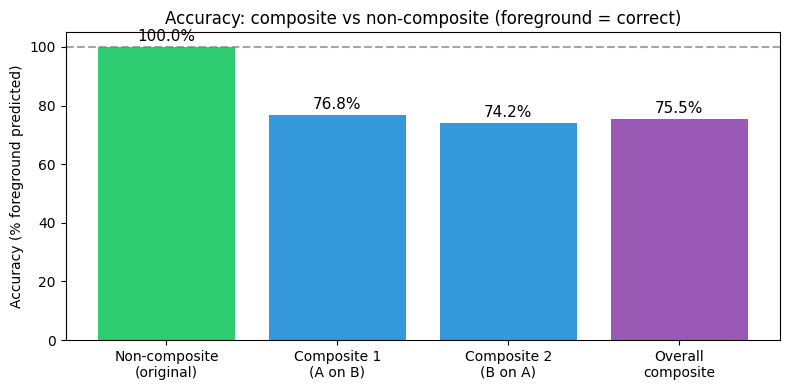

In [77]:
# Compute accuracy from results (works even if aggregate cell was skipped)
n = len(results)
if n == 0:
    print("No data in 'results'. Run the swap loop (Section 6) first — it can take a few minutes for 50 pairs (loading images + CLIP).")
    print("Run cells in order: 1) Setup, 2) Config, 3) Load CLIP, 4) Load COCO, 5) Helpers, 6) Swap loop (wait for tqdm to finish), then this chart.")
else:
    print(f"Using {n} pairs for chart.")
c1 = sum(1 for r in results if r.get("correct1", (r["closer1"] == "A")))
c2 = sum(1 for r in results if r.get("correct2", (r["closer2"] == "B")))
acc_comp1 = 100 * c1 / n if n else 0
acc_comp2 = 100 * c2 / n if n else 0
acc_overall = 100 * (c1 + c2) / (2 * n) if n else 0

fig, ax = plt.subplots(figsize=(8, 4))
labels = ["Non-composite\n(original)", "Composite 1\n(A on B)", "Composite 2\n(B on A)", "Overall\ncomposite"]
values = [100.0, acc_comp1, acc_comp2, acc_overall]
colors = ["#2ecc71", "#3498db", "#3498db", "#9b59b6"]
bars = ax.bar(labels, values, color=colors)
ax.set_ylabel("Accuracy (% foreground predicted)")
ax.set_ylim(0, 105)
ax.axhline(y=100, color="gray", linestyle="--", alpha=0.7, label="baseline")
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, f"{v:.1f}%", ha="center", fontsize=11)
ax.set_title("Accuracy: composite vs non-composite (foreground = correct)")
plt.tight_layout()
plt.show()

## 7c. Research-level: confidence & entropy (aligned with main eval)

Same style as notebook 1: we use **softmax** over the two options (A vs B) to get a probability. Here we compare **mean confidence** when the model was correct (foreground predicted) vs wrong (background followed), and **entropy** (uncertainty).

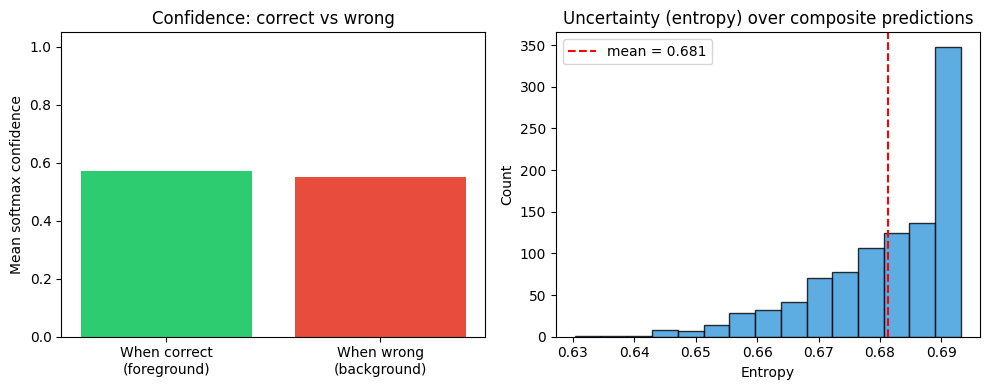

In [79]:
# Recompute if aggregate cell was skipped; handle old results without conf/ent
n = len(results)
has_conf = n and "conf1" in results[0]
if n and has_conf:
    confs = [r["conf1"] for r in results] + [r["conf2"] for r in results]
    correct_flags = [r["correct1"] for r in results] + [r["correct2"] for r in results]
    conf_correct = [c for c, ok in zip(confs, correct_flags) if ok]
    conf_wrong = [c for c, ok in zip(confs, correct_flags) if not ok]
    ents = [r["ent1"] for r in results] + [r["ent2"] for r in results]
    mean_conf_correct = np.mean(conf_correct) if conf_correct else 0
    mean_conf_wrong = np.mean(conf_wrong) if conf_wrong else 0
    mean_ent = np.mean(ents) if ents else 0
else:
    mean_conf_correct = mean_conf_wrong = mean_ent = 0
    ents = []
    if n and not has_conf:
        print("Results have no confidence/entropy (old run). Re-run Section 6 (swap loop) then re-run this cell.")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(["When correct\n(foreground)", "When wrong\n(background)"], [mean_conf_correct, mean_conf_wrong], color=["#2ecc71", "#e74c3c"])
axes[0].set_ylabel("Mean softmax confidence")
axes[0].set_title("Confidence: correct vs wrong")
axes[0].set_ylim(0, 1.05)
if ents:
    axes[1].hist(ents, bins=15, color="#3498db", alpha=0.8, edgecolor="black")
    axes[1].axvline(mean_ent, color="red", linestyle="--", label=f"mean = {mean_ent:.3f}")
    axes[1].legend()
else:
    axes[1].text(0.5, 0.5, "No entropy data. Re-run Section 6.", ha="center", va="center", transform=axes[1].transAxes)
axes[1].set_xlabel("Entropy")
axes[1].set_ylabel("Count")
axes[1].set_title("Uncertainty (entropy) over composite predictions")
plt.tight_layout()
plt.show()

In [80]:
def bbox_union(coco, img_id: int) -> Tuple[int,int,int,int]:
    """Union of all object bboxes in this image (all categories)."""
    anns = coco.loadAnns(coco.getAnnIds(imgIds=[img_id]))
    if not anns:
        return None
    boxes = []
    for a in anns:
        x, y, w, h = a["bbox"]
        boxes.append((int(x), int(y), int(x+w), int(y+h)))
    return (min(b[0] for b in boxes), min(b[1] for b in boxes), max(b[2] for b in boxes), max(b[3] for b in boxes))

def composite_swap(img_a: Image.Image, img_b: Image.Image, bbox_a: tuple, bbox_b: tuple):
    x1a, y1a, x2a, y2a = bbox_a
    x1b, y1b, x2b, y2b = bbox_b
    fg_a = img_a.crop(bbox_a)
    fg_b = img_b.crop(bbox_b)
    wb, hb = x2b - x1b, y2b - y1b
    wa, ha = x2a - x1a, y2a - y1a
    out1 = img_b.copy()
    out1.paste(fg_a.resize((wb, hb), Image.Resampling.LANCZOS), (x1b, y1b))
    out2 = img_a.copy()
    out2.paste(fg_b.resize((wa, ha), Image.Resampling.LANCZOS), (x1a, y1a))
    return out1, out2

def run_one_pair(id_a: int, id_b: int):
    """Load images, build composites; CLIP similarity + softmax -> confidence & entropy. Returns (closer1, closer2, conf1, conf2, ent1, ent2, img_a, img_b, comp1, comp2) or None."""
    info_a = coco.loadImgs([id_a])[0]
    info_b = coco.loadImgs([id_b])[0]
    path_a = img_dir / info_a["file_name"]
    path_b = img_dir / info_b["file_name"]
    if not path_a.exists() or not path_b.exists():
        return None
    img_a = Image.open(path_a).convert("RGB")
    img_b = Image.open(path_b).convert("RGB")
    bbox_a = bbox_union(coco, id_a)
    bbox_b = bbox_union(coco, id_b)
    if not bbox_a or not bbox_b:
        return None
    comp1, comp2 = composite_swap(img_a, img_b, bbox_a, bbox_b)
    imgs = [img_a, img_b, comp1, comp2]
    inputs = clip_processor(images=imgs, return_tensors="pt").to(device)
    with torch.no_grad():
        out = clip_model.get_image_features(inputs["pixel_values"])
    if isinstance(out, torch.Tensor):
        feats = out
    elif hasattr(out, "pooler_output") and out.pooler_output is not None:
        feats = out.pooler_output
    else:
        feats = out[0]  # BaseModelOutput: first element is usually the hidden state / pooled tensor
    if feats.dim() == 3:
        feats = feats.mean(dim=1)  # (batch, seq, dim) -> (batch, dim)
    feats = feats.float() / feats.norm(dim=-1, keepdim=True)
    emb_a, emb_b, emb1, emb2 = feats[0], feats[1], feats[2], feats[3]
    sim_1_a = (emb1 @ emb_a).item()
    sim_1_b = (emb1 @ emb_b).item()
    sim_2_a = (emb2 @ emb_a).item()
    sim_2_b = (emb2 @ emb_b).item()
    temp = CONFIG.get("softmax_temperature", 1.0)
    logits1 = torch.tensor([sim_1_a, sim_1_b], device=device, dtype=torch.float32) / temp
    logits2 = torch.tensor([sim_2_a, sim_2_b], device=device, dtype=torch.float32) / temp
    probs1 = F.softmax(logits1, dim=0).cpu().numpy()
    probs2 = F.softmax(logits2, dim=0).cpu().numpy()
    closer1 = "A" if sim_1_a >= sim_1_b else "B"
    closer2 = "A" if sim_2_a >= sim_2_b else "B"
    conf1 = float(probs1[0] if closer1 == "A" else probs1[1])
    conf2 = float(probs2[0] if closer2 == "A" else probs2[1])
    ent1 = -np.sum(probs1 * np.log(probs1 + 1e-8))
    ent2 = -np.sum(probs2 * np.log(probs2 + 1e-8))
    return (closer1, closer2, conf1, conf2, ent1, ent2, img_a, img_b, comp1, comp2)

## 6. Run swap over many pairs and collect results

**Note:** This loop can take 10–20+ minutes for 500 pairs (or longer if using all pairs). Wait until the progress bar finishes before running the charts below.

In [81]:
results = []  # id_a, id_b, closer1/2, correct1/2, conf1/2, ent1/2
example_outputs = []

for i, (id_a, id_b) in enumerate(tqdm(pair_ids, desc="Swap")):
    out = run_one_pair(id_a, id_b)
    if out is None:
        continue
    closer1, closer2, conf1, conf2, ent1, ent2, img_a, img_b, comp1, comp2 = out
    correct1 = (closer1 == "A")
    correct2 = (closer2 == "B")
    results.append({"id_a": id_a, "id_b": id_b, "closer1": closer1, "closer2": closer2, "correct1": correct1, "correct2": correct2, "conf1": conf1, "conf2": conf2, "ent1": ent1, "ent2": ent2})
    if len(example_outputs) < CONFIG["num_example_outputs"]:
        example_outputs.append({"closer1": closer1, "closer2": closer2, "correct1": correct1, "correct2": correct2, "conf1": conf1, "conf2": conf2, "img_a": img_a, "img_b": img_b, "comp1": comp1, "comp2": comp2})

print(f"Successfully ran {len(results)} pairs.")

Swap: 100%|██████████| 1000/1000 [01:10<00:00, 14.19it/s]

Successfully ran 1000 pairs.


## 7. Aggregate results (summary table)

In [82]:
total = len(results)
correct1_count = sum(1 for r in results if r["correct1"])
correct2_count = sum(1 for r in results if r["correct2"])
wrong_count = 2 * total - correct1_count - correct2_count
acc_comp1 = 100 * correct1_count / total if total else 0
acc_comp2 = 100 * correct2_count / total if total else 0
acc_overall = 100 * (correct1_count + correct2_count) / (2 * total) if total else 0

# Softmax confidence & entropy (only if results have conf1/conf2 from current run)
has_conf = results and "conf1" in results[0]
if has_conf:
    confs = [r["conf1"] for r in results] + [r["conf2"] for r in results]
    correct_flags = [r["correct1"] for r in results] + [r["correct2"] for r in results]
    conf_correct = [c for c, ok in zip(confs, correct_flags) if ok]
    conf_wrong = [c for c, ok in zip(confs, correct_flags) if not ok]
    ents = [r["ent1"] for r in results] + [r["ent2"] for r in results]
    mean_conf_correct = np.mean(conf_correct) if conf_correct else 0
    mean_conf_wrong = np.mean(conf_wrong) if conf_wrong else 0
    mean_ent = np.mean(ents) if ents else 0
else:
    mean_conf_correct = mean_conf_wrong = mean_ent = 0
    print("  [Re-run Section 6 (swap loop) to get confidence & entropy; results are from an older run.]")

print("Foreground-as-answer: correct = model predicted the pasted subject (main body).")
print(f"  Composite 1: {correct1_count}/{total} correct -> {acc_comp1:.1f}%")
print(f"  Composite 2: {correct2_count}/{total} correct -> {acc_comp2:.1f}%")
print(f"  Overall composite accuracy: {acc_overall:.1f}%")
print(f"  Wrong: {wrong_count} / {2*total}")
if has_conf:
    print("  --- Softmax confidence (like main eval) ---")
    print(f"  Mean confidence when CORRECT: {mean_conf_correct:.4f}")
    print(f"  Mean confidence when WRONG:   {mean_conf_wrong:.4f}")
    print(f"  Mean entropy (uncertainty):    {mean_ent:.4f}")

Foreground-as-answer: correct = model predicted the pasted subject (main body).
  Composite 1: 755/1000 correct -> 75.5%
  Composite 2: 771/1000 correct -> 77.1%
  Overall composite accuracy: 76.3%
  Wrong: 474 / 2000
  --- Softmax confidence (like main eval) ---
  Mean confidence when CORRECT: 0.5709
  Mean confidence when WRONG:   0.5492
  Mean entropy (uncertainty):    0.6816


## 8. Show example outputs (2×2 grids)

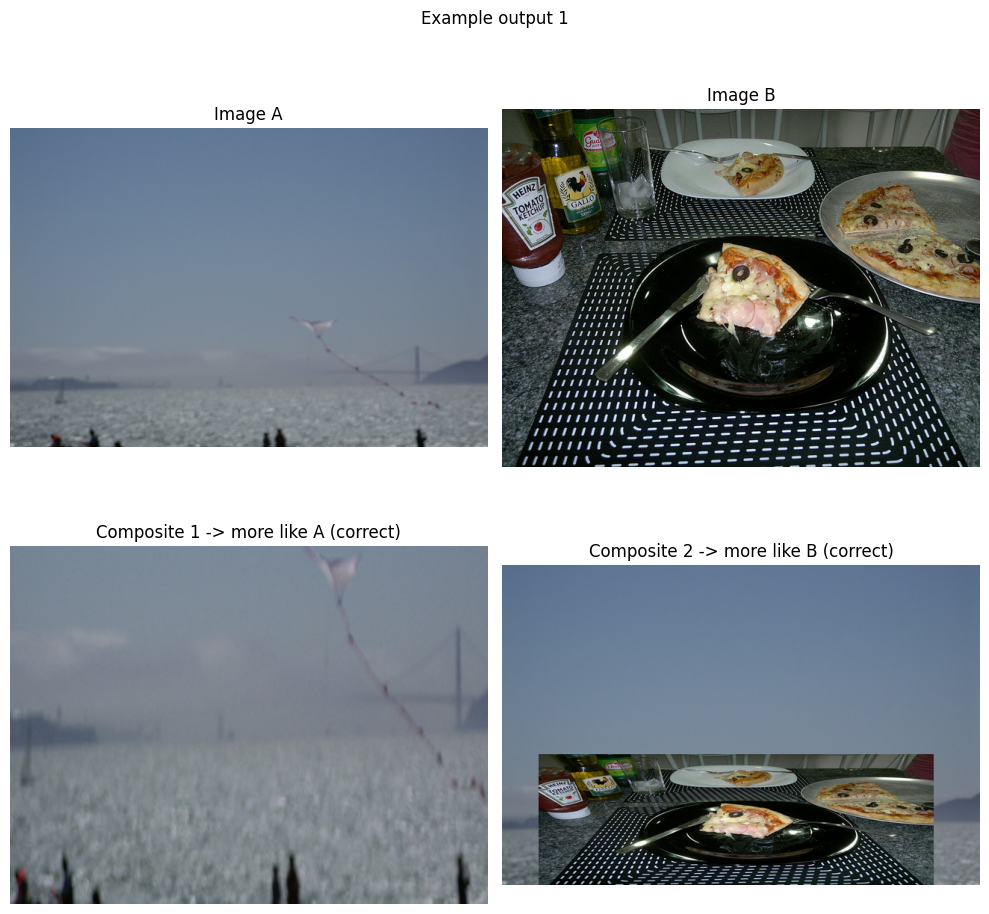

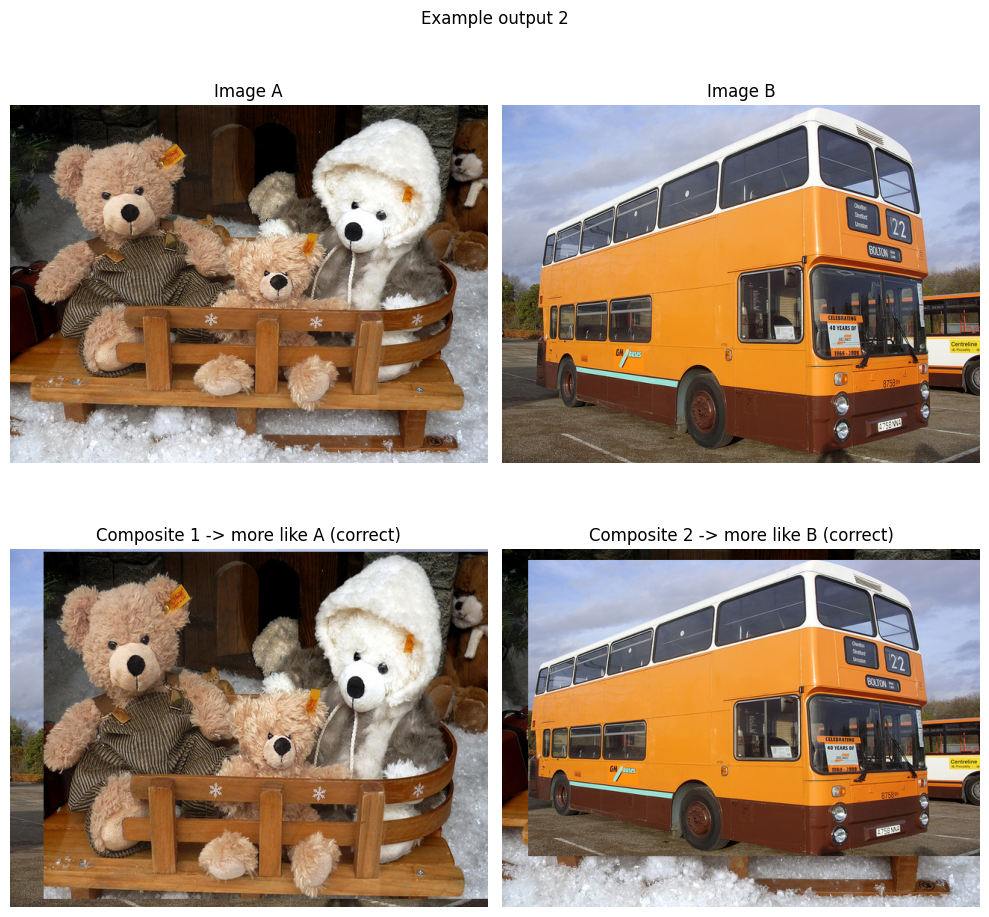

In [83]:
for idx, ex in enumerate(example_outputs):
    fig, axes = plt.subplots(2, 2, figsize=(10, 10))
    axes[0, 0].imshow(ex["img_a"]); axes[0, 0].set_title("Image A"); axes[0, 0].axis("off")
    axes[0, 1].imshow(ex["img_b"]); axes[0, 1].set_title("Image B"); axes[0, 1].axis("off")
    c1 = "correct" if ex["correct1"] else "wrong"
    c2 = "correct" if ex["correct2"] else "wrong"
    axes[1, 0].imshow(ex["comp1"]); axes[1, 0].set_title(f"Composite 1 -> more like {ex['closer1']} ({c1})"); axes[1, 0].axis("off")
    axes[1, 1].imshow(ex["comp2"]); axes[1, 1].set_title(f"Composite 2 -> more like {ex['closer2']} ({c2})"); axes[1, 1].axis("off")
    fig.suptitle(f"Example output {idx+1}", fontsize=12)
    plt.tight_layout()
    plt.show()

## 9. Save results for report

In [ ]:
import json

summary = {
    "n_pairs": total,
    "accuracy_composite1": acc_comp1,
    "accuracy_composite2": acc_comp2,
    "accuracy_overall_composite": acc_overall,
    "correct1_count": correct1_count,
    "correct2_count": correct2_count,
    "wrong_count": wrong_count,
    "mean_confidence_correct": float(mean_conf_correct),
    "mean_confidence_wrong": float(mean_conf_wrong),
    "mean_entropy": float(mean_ent),
}
out_path = Path("results/swap_experiment/swap_results.json")
out_path.parent.mkdir(parents=True, exist_ok=True)
with open(out_path, "w") as f:
    json.dump({"summary": summary, "results": results}, f, indent=2)
print(f"Saved to {out_path}")

## 10. Rigor & variance: uncertainty and reporting (严谨度)

We report **point estimates with uncertainty** (variance, 95% CI) so results are interpretable and rigorous. We care about variance because the 75% accuracy could vary across runs or subsets; CIs show the range consistent with the data.

Overall composite accuracy: 76.30%  (95% CI: [74.40%, 78.10%], bootstrap std = 0.93%)
Sample size: 1000 pairs, 2000 composite evaluations.


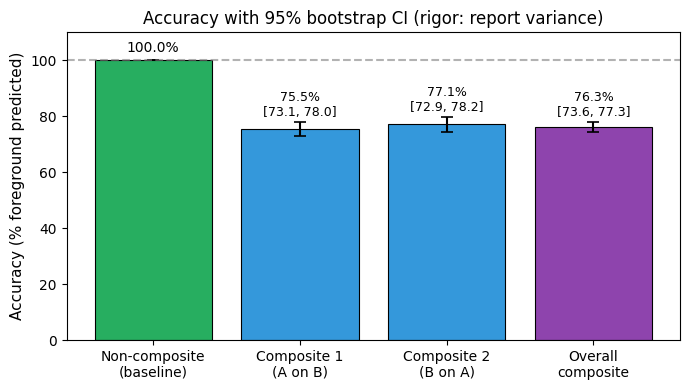

In [84]:
# Bootstrap 95% CI for accuracy (variance / uncertainty)
n_boot = 1000
rng = np.random.default_rng(42)
n = len(results)
if n >= 10 and "correct1" in results[0]:
    # Per-composite outcomes: 2*n (comp1 correct/wrong, comp2 correct/wrong)
    outcomes = np.array([r["correct1"] for r in results] + [r["correct2"] for r in results], dtype=float)
    boot_accs = []
    for _ in range(n_boot):
        idx = rng.integers(0, 2 * n, size=2 * n)
        boot_accs.append(100 * outcomes[idx].mean())
    boot_accs = np.array(boot_accs)
    ci_low = np.percentile(boot_accs, 2.5)
    ci_high = np.percentile(boot_accs, 97.5)
    std_acc = boot_accs.std()
    print(f"Overall composite accuracy: {acc_overall:.2f}%  (95% CI: [{ci_low:.2f}%, {ci_high:.2f}%], bootstrap std = {std_acc:.2f}%)")
    print(f"Sample size: {n} pairs, {2*n} composite evaluations.")

    # Professional bar chart with error bars (95% CI)
    fig, ax = plt.subplots(figsize=(7, 4))
    labels = ["Non-composite\n(baseline)", "Composite 1\n(A on B)", "Composite 2\n(B on A)", "Overall\ncomposite"]
    # Bootstrap CI for comp1, comp2 separately (resample pairs)
    o1 = np.array([r["correct1"] for r in results], dtype=float)
    o2 = np.array([r["correct2"] for r in results], dtype=float)
    boot1 = [100 * o1[rng.integers(0, n, size=n)].mean() for _ in range(n_boot)]
    boot2 = [100 * o2[rng.integers(0, n, size=n)].mean() for _ in range(n_boot)]
    vals = [100.0, acc_comp1, acc_comp2, acc_overall]
    errs = [0, np.percentile(boot1, 97.5) - acc_comp1, np.percentile(boot2, 97.5) - acc_comp2, ci_high - acc_overall]
    errs_low = [0, acc_comp1 - np.percentile(boot1, 2.5), acc_comp2 - np.percentile(boot2, 2.5), acc_overall - ci_low]
    yerr = np.array([errs_low, errs])
    colors = ["#27ae60", "#3498db", "#3498db", "#8e44ad"]
    bars = ax.bar(labels, vals, color=colors, edgecolor="black", linewidth=0.8)
    ax.errorbar(labels, vals, yerr=yerr, fmt="none", color="black", capsize=4, capthick=1.2)
    ax.set_ylabel("Accuracy (% foreground predicted)", fontsize=11)
    ax.set_ylim(0, 110)
    ax.axhline(100, color="gray", linestyle="--", alpha=0.6)
    ax.set_title("Accuracy with 95% bootstrap CI (rigor: report variance)", fontsize=12)
    for i, (v, lo, hi) in enumerate(zip(vals, [v - yerr[0][i] for i in range(4)], [v + yerr[1][i] for i in range(4)])):
        if i == 0:
            ax.text(i, v + 3, f"{v:.1f}%", ha="center", fontsize=10)
        else:
            ax.text(i, min(v + yerr[1][i] + 2, 108), f"{v:.1f}%\n[{lo:.1f}, {hi:.1f}]", ha="center", fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    print("Need at least 10 results with correct1/correct2 for bootstrap. Run Section 6 first.")

## 11. Why do errors happen? Cases we might miss? (原因与遗漏)

We analyze **when** the model is wrong (confidence, entropy) and **possible reasons** so we can explain variance and think about cases we may have missed.

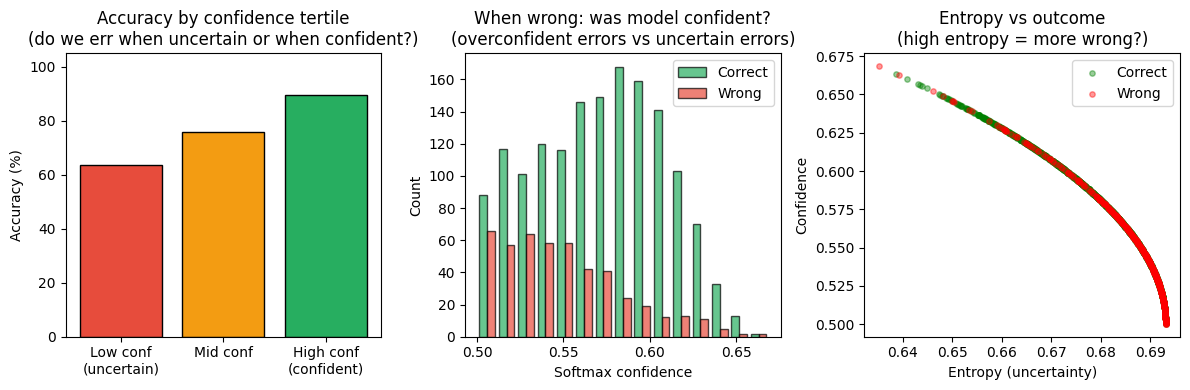

--- Interpretation ---
When WRONG: mean confidence = 0.549 (if high, model was overconfident but followed background).
When CORRECT: mean confidence = 0.571.
Possible reasons for ~25%% wrong: background dominant in scene, small foreground, or CLIP relies on context.


In [85]:
# Analysis: when do errors happen? (confidence & entropy)
if not n or "conf1" not in results[0]:
    print("Re-run Section 6 to get confidence/entropy, then re-run this cell.")
else:
    confs = np.array([r["conf1"] for r in results] + [r["conf2"] for r in results])
    correct_flags = np.array([r["correct1"] for r in results] + [r["correct2"] for r in results])
    ents = np.array([r["ent1"] for r in results] + [r["ent2"] for r in results])

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    # (1) Accuracy by confidence tertile: are errors more when model is uncertain or overconfident?
    tertiles = np.percentile(confs, [33.33, 66.67])
    low = confs <= tertiles[0]
    mid = (confs > tertiles[0]) & (confs <= tertiles[1])
    high = confs > tertiles[1]
    acc_low = 100 * correct_flags[low].mean() if low.sum() else 0
    acc_mid = 100 * correct_flags[mid].mean() if mid.sum() else 0
    acc_high = 100 * correct_flags[high].mean() if high.sum() else 0
    axes[0].bar(["Low conf\n(uncertain)", "Mid conf", "High conf\n(confident)"], [acc_low, acc_mid, acc_high], color=["#e74c3c", "#f39c12", "#27ae60"], edgecolor="black")
    axes[0].set_ylabel("Accuracy (%)")
    axes[0].set_title("Accuracy by confidence tertile\n(do we err when uncertain or when confident?)")
    axes[0].set_ylim(0, 105)

    # (2) When WRONG: distribution of confidence (overconfident errors?)
    wrong_confs = confs[~correct_flags]
    right_confs = confs[correct_flags]
    axes[1].hist([right_confs, wrong_confs], bins=15, label=["Correct", "Wrong"], color=["#27ae60", "#e74c3c"], alpha=0.7, edgecolor="black")
    axes[1].set_xlabel("Softmax confidence")
    axes[1].set_ylabel("Count")
    axes[1].set_title("When wrong: was model confident?\n(overconfident errors vs uncertain errors)")
    axes[1].legend()

    # (3) Entropy vs correct: higher entropy -> more errors?
    axes[2].scatter(ents[correct_flags], confs[correct_flags], alpha=0.4, s=15, c="green", label="Correct")
    axes[2].scatter(ents[~correct_flags], confs[~correct_flags], alpha=0.4, s=15, c="red", label="Wrong")
    axes[2].set_xlabel("Entropy (uncertainty)")
    axes[2].set_ylabel("Confidence")
    axes[2].set_title("Entropy vs outcome\n(high entropy = more wrong?)")
    axes[2].legend()

    plt.tight_layout()
    plt.show()

    # Short summary for report
    print("--- Interpretation ---")
    print(f"When WRONG: mean confidence = {wrong_confs.mean():.3f} (if high, model was overconfident but followed background).")
    print(f"When CORRECT: mean confidence = {right_confs.mean():.3f}.")
    print("Possible reasons for ~25%% wrong: background dominant in scene, small foreground, or CLIP relies on context.")

### Rigor (严谨度) & variance

- **Uncertainty:** We report 95% bootstrap CI so readers see the range consistent with the data; variance across bootstrap samples reflects sampling variation.
- **Sample size:** Always report *n* (pairs and composite evaluations) so results are interpretable.

### Why ~25% wrong? Cases we might miss?

- **Background dominant:** When the background scene is large or salient, CLIP may align the composite more with the background donor.
- **Foreground size:** Small pasted region vs large background can bias the embedding toward the background.
- **What we do not measure:** We only compare "more like A" vs "more like B"; we do not capture other failures (e.g. neither A nor B, or wrong for a different reason). So the 25% is a *lower bound* on "influenced by background" in a broader sense.
- **Overconfident errors:** If wrong predictions have high confidence (see chart above), the model is systematically following the background rather than being uncertain; that supports "background dominance" as an explanation.